# Proyecto 2 — Análisis Exploratorio
## Reto #17 — MosquitoAlert Challenge 2023 (AIcrowd)
**CC3084 — Data Science | UVG | Semestre II — 2026**

Competencia: https://www.aicrowd.com/challenges/mosquitoalert-challenge-2023

| Integrante | Módulo asignado | GitHub |
|---|---|---|
| `[Nombre 1]` | Investigación del tema + Situación problemática + Problema científico | `[@usuario]` |
| `[Nombre 2]` | Objetivos + Descripción de datos + Limpieza | `[@usuario]` |
| `[Nombre 3]` | Análisis exploratorio — variables cuantitativas y categóricas | `[@usuario]` |
| `[Nombre 4]` | Análisis exploratorio — cruces, outliers, inspección visual + Conclusiones | `[@usuario]` |

---
### Cómo usar este notebook
1. **No reordenes ni borres secciones.**Cada una corresponde a un punto de la rúbrica.
2. Las celdas de código de las secciones 5–7 (carga, limpieza, EDA base) **ya funcionan**— corren en modo demo con datos sintéticos si todavía no tienen el dataset real descargado. Cuando descarguen `train.csv` y las imágenes desde la pestaña *Resources* de AIcrowd, colóquenlos en `data/raw/` y el notebook usará los datos reales automáticamente (ver Sección 2).
3. Busca los bloques marcados `# TODO (Responsable: ...)` — ahí es donde cada quien "colorea" su parte: research, interpretación o decisiones.
4. Ejecuta todo el notebook de arriba hacia abajo (`Run All`) antes de hacer commit, para asegurarte de que no rompiste nada.


## 0. Configuración e importaciones

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Carga de Datos

**Responsable:**`[Nombre 2]`

Descarga `train.csv` y la carpeta de imágenes desde la pestaña **Resources**del reto en AIcrowd
(requiere estar inscritos en la competencia) y colócalos así:

```
data/raw/train.csv
data/raw/images/<archivo>.jpeg
```

Mientras no tengan los datos reales, `DEMO_MODE` genera un dataset sintético con la
**misma estructura de columnas y la misma distribución de clases reportada oficialmente**
(ver tabla de clases del reto), para que el resto del notebook corra sin errores desde ya.


In [2]:
DATA_DIR = "../data/raw"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "images")

# Distribución oficial de clases reportada por AIcrowd para el subset de entrenamiento (8025 imgs)
OFFICIAL_CLASS_COUNTS = {
    "aegypti": 38,
    "albopictus": 3567,
    "anopheles": 63,
    "culex": 3544,
    "culiseta": 492,
    "japonicus/koreicus": 321,
}

def make_synthetic_train_df(class_counts=OFFICIAL_CLASS_COUNTS, seed=RANDOM_SEED):
    """Genera un DataFrame sintético con la misma forma que train.csv del reto,
    replicando la proporción real de clases (útil para probar el pipeline de EDA
    antes de tener el dataset real descargado)."""
    rng = np.random.default_rng(seed)
    rows = []
    img_id = 0
    for cls, n in class_counts.items():
        for _ in range(n):
            width = int(rng.normal(1200, 250))
            height = int(rng.normal(900, 200))
            width, height = max(width, 200), max(height, 200)
            bw = rng.uniform(0.05, 0.4) * width
            bh = rng.uniform(0.05, 0.4) * height
            xtl = rng.uniform(0, width - bw)
            ytl = rng.uniform(0, height - bh)
            rows.append({
                "img_fname": f"synthetic_{img_id:05d}.jpeg",
                "width": width,
                "height": height,
                "bbx_xtl": round(xtl, 1),
                "bbx_ytl": round(ytl, 1),
                "bbx_xbr": round(xtl + bw, 1),
                "bbx_ybr": round(ytl + bh, 1),
                "class_label": cls,
            })
            img_id += 1
    df = pd.DataFrame(rows).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df

USE_REAL_DATA = os.path.exists(TRAIN_CSV)

if USE_REAL_DATA:
    train_df = pd.read_csv(TRAIN_CSV)
    print(f"Datos reales cargados desde {TRAIN_CSV} — {len(train_df)} filas.")
else:
    train_df = make_synthetic_train_df()
    print("DEMO MODE: no se encontró data/raw/train.csv — usando datos sintéticos "
          f"({len(train_df)} filas) solo para validar el pipeline. "
          "Reemplacen con el dataset real antes de la entrega.")

train_df.head()


DEMO MODE: no se encontró data/raw/train.csv — usando datos sintéticos (8025 filas) solo para validar el pipeline. Reemplacen con el dataset real antes de la entrega.


,img_fname,width,height,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label
0,synthetic_00538.jpeg,1415,935,886.1,88.9,1199.0,147.8,albopictus
1,synthetic_06810.jpeg,1107,890,378.0,576.6,464.1,811.2,culex
2,synthetic_06630.jpeg,1078,1004,394.2,115.5,689.1,184.9,culex
3,synthetic_07284.jpeg,1396,874,1006.6,371.5,1244.3,472.5,culiseta
4,synthetic_06697.jpeg,1448,1111,398.1,747.8,656.6,1024.4,culex


## 1. Investigación del Tema

**Responsable:**`[Nombre 1]`

> Actividad 1 de la guía: investigar el problema para entender qué patrón deben reconocer los
> algoritmos. Completa cada punto con 3–5 líneas. Cita tus fuentes al final de la sección.

### 1.1 El problema de salud pública
- ¿Por qué es importante distinguir especies/géneros de mosquitos? ¿Qué enfermedades transmite cada clase del dataset?
- `# TODO (Responsable: [Nombre 1])`

### 1.2 Las 6 clases del reto y cómo se distinguen morfológicamente
Usa la tabla oficial del reto como punto de partida y amplíala con literatura entomológica:

| Clase (`class_label`) | Nombre | Tipo | Nota |
|---|---|---|---|
| `aegypti` | *Aedes aegypti* | Especie | Vector de dengue, zika, chikungunya |
| `albopictus` | *Aedes albopictus* | Especie | Clase mayoritaria del dataset |
| `anopheles` | *Anopheles* | Género | Vector de malaria |
| `culex` | *Culex* | Género | Difícil de diferenciar a nivel de especie |
| `culiseta` | *Culiseta* | Género | — |
| `japonicus/koreicus` | *Aedes japonicus/koreicus* | Complejo de especies | Muy similares entre sí, incluso para expertos |

`# TODO (Responsable: [Nombre 1])`: para cada clase, agregar 1–2 rasgos visuales distintivos
(patrón de escamas, color, tamaño) que un modelo de visión artificial podría aprender a detectar.

### 1.3 Por qué es un problema de Visión Artificial no trivial
- Tamaño pequeño del objeto dentro de la imagen (detección de objetos pequeños).
- Fuerte desbalance de clases (`albopictus`/`culex` dominan; `aegypti` casi no tiene ejemplos).
- Imágenes tomadas por ciudadanos con celulares: iluminación, ángulo y calidad muy variables.
- `# TODO (Responsable: [Nombre 1])`: investigar qué técnicas se usan típicamente
  (CNNs, transfer learning, detección tipo YOLO, aumentos de datos para clases minoritarias) y
  resumir en 1 párrafo. El propio reto ofrece un baseline con YOLOv5 — vale la pena revisarlo.

### 1.4 Fuentes
`# TODO`: listar aquí (formato APA o similar) los artículos/páginas consultados.


## 2. Situación Problemática  *(10 pts)*

**Responsable:**`[Nombre 1]`

`# TODO`: 1–2 párrafos. Ideas guía: identificación manual de especies = lenta, requiere
expertos escasos; Mosquito Alert usa ciencia ciudadana para escalar la recolección de imágenes,
pero la validación experta no escala igual de rápido; automatizar la clasificación acelera la
vigilancia entomológica y la respuesta de salud pública.

---

## 3. Problema Científico  *(10 pts)*

**Responsable:**`[Nombre 1]`

`# TODO`: enunciar como pregunta de investigación. Ejemplo de forma (ajustar):
> ¿Es posible construir un modelo de clasificación/detección que identifique correctamente la
> especie o género de un mosquito a partir de fotografías tomadas por ciudadanos, a pesar del
> fuerte desbalance de clases y la variabilidad de las condiciones de captura?

---

## 4. Objetivos  *(10 pts)*

**Responsable:**`[Nombre 2]`

**Objetivo general:**`# TODO`

**Objetivos específicos:**
1. `# TODO` (ej. cuantificar el desbalance de clases y su impacto potencial en el modelado)
2. `# TODO` (ej. caracterizar la calidad y variabilidad de las imágenes y bounding boxes)
3. *(opcional)* `# TODO`


## 5. Descripción de los Datos  *(20 pts)*

**Responsable:**`[Nombre 2]`

Código base ya funcional. Ejecútenlo tal cual sobre el dataset real y escriban su interpretación
en la celda de markdown al final de la sección.


In [3]:
print(f"Observaciones (filas): {train_df.shape[0]}")
print(f"Variables (columnas): {train_df.shape[1]}")
train_df.dtypes


Observaciones (filas): 8025
Variables (columnas): 8


img_fname          str
width            int64
height           int64
bbx_xtl        float64
bbx_ytl        float64
bbx_xbr        float64
bbx_ybr        float64
class_label        str
dtype: object

In [4]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8025 entries, 0 to 8024
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   img_fname    8025 non-null   str    
 1   width        8025 non-null   int64  
 2   height       8025 non-null   int64  
 3   bbx_xtl      8025 non-null   float64
 4   bbx_ytl      8025 non-null   float64
 5   bbx_xbr      8025 non-null   float64
 6   bbx_ybr      8025 non-null   float64
 7   class_label  8025 non-null   str    
dtypes: float64(4), int64(2), str(2)
memory usage: 501.7 KB


In [5]:
print("Valores faltantes por columna:")
train_df.isnull().sum()


Valores faltantes por columna:


img_fname      0
width          0
height         0
bbx_xtl        0
bbx_ytl        0
bbx_xbr        0
bbx_ybr        0
class_label    0
dtype: int64

In [6]:
print(f"Clases únicas: {train_df['class_label'].nunique()}")
print(f"Imágenes con nombre de archivo duplicado: {train_df['img_fname'].duplicated().sum()}")
train_df.describe()


Clases únicas: 6
Imágenes con nombre de archivo duplicado: 0


,width,height,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr
count,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000
mean,1203.520498,897.691713,466.493632,345.555215,737.849545,548.371103
std,250.901374,202.133280,296.548634,225.607563,321.031281,244.569461
min,200.000000,200.000000,0.000000,0.100000,52.200000,34.600000
25%,1033.000000,761.000000,221.900000,163.800000,491.100000,360.000000
50%,1198.000000,895.000000,439.100000,320.200000,722.100000,529.500000
75%,1374.000000,1034.000000,672.000000,497.900000,963.600000,711.300000
max,2206.000000,1765.000000,1564.500000,1292.800000,1890.000000,1549.700000


### Interpretación (completar)
`# TODO (Responsable: [Nombre 2])`: describir en prosa cuántas observaciones y variables hay,
qué tipo es cada una (imagen, bounding box numérico, clase categórica), y si hay valores
faltantes o duplicados que haya que resolver.


## 6. Limpieza y Preprocesamiento

**Responsable:**`[Nombre 2]`

Código base: crea variables derivadas del bounding box y valida su consistencia geométrica.
Ya corre; agreguen aquí cualquier limpieza adicional que encuentren necesaria al inspeccionar
los datos reales (imágenes corruptas, rutas rotas, etc.).


In [7]:
# Variables derivadas del bounding box — útiles para el análisis cuantitativo (sección 7)
train_df["bbx_width"] = train_df["bbx_xbr"] - train_df["bbx_xtl"]
train_df["bbx_height"] = train_df["bbx_ybr"] - train_df["bbx_ytl"]
train_df["bbx_area"] = train_df["bbx_width"] * train_df["bbx_height"]
train_df["image_area"] = train_df["width"] * train_df["height"]
train_df["bbx_area_ratio"] = train_df["bbx_area"] / train_df["image_area"]
train_df["aspect_ratio"] = train_df["width"] / train_df["height"]

# Validación de consistencia geométrica del bounding box
invalid_bbox = train_df[
    (train_df["bbx_width"] <= 0) |
    (train_df["bbx_height"] <= 0) |
    (train_df["bbx_xbr"] > train_df["width"]) |
    (train_df["bbx_ybr"] > train_df["height"])
]
print(f"Filas con bounding box inconsistente: {len(invalid_bbox)}")
invalid_bbox.head()


Filas con bounding box inconsistente: 0


,img_fname,width,height,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label,bbx_width,bbx_height,bbx_area,image_area,bbx_area_ratio,aspect_ratio


In [8]:
# TODO (Responsable: [Nombre 2]): si `invalid_bbox` no está vacío al usar el dataset real,
# decidir y documentar aquí qué se hace (¿se corrige, se descarta, se marca?) y por qué.

# TODO: verificar que los archivos de imagen listados en train_df realmente existan en IMAGES_DIR
if USE_REAL_DATA:
    existing = train_df["img_fname"].apply(lambda f: os.path.exists(os.path.join(IMAGES_DIR, f)))
    print(f"Imágenes referenciadas que faltan en disco: {(~existing).sum()} de {len(train_df)}")
else:
    print("DEMO MODE: se omite verificación de archivos en disco (no hay imágenes sintéticas en disco).")


DEMO MODE: se omite verificación de archivos en disco (no hay imágenes sintéticas en disco).


## 7. Análisis Exploratorio de Datos  *(30 pts — la sección con más peso)*

Dividida en sub-secciones para que cada integrante tome una parte clara. Todo el código corre
en modo demo; al usar el dataset real, solo hace falta escribir la interpretación.


### 7.1 Variables cuantitativas — estadística descriptiva

**Responsable:**`[Nombre 3]`


In [9]:
numeric_cols = ["width", "height", "bbx_width", "bbx_height", "bbx_area", "bbx_area_ratio", "aspect_ratio"]
train_df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
width,8025.0,1203.520498,250.901374,200.000000,1033.000000,1198.000000,1374.000000,2206.000000
height,8025.0,897.691713,202.133280,200.000000,761.000000,895.000000,1034.000000,1765.000000
bbx_width,8025.0,271.355913,137.910452,12.100000,156.300000,257.900000,373.100000,772.300000
bbx_height,8025.0,202.815888,103.418588,23.300000,117.400000,193.500000,275.200000,619.100000
bbx_area,8025.0,55052.129707,42136.570237,1886.680000,23184.400000,43274.000000,76383.880000,294167.400000
bbx_area_ratio,8025.0,0.050853,0.033892,0.002753,0.023587,0.042091,0.072559,0.158594
aspect_ratio,8025.0,1.423238,0.509261,0.251244,1.089242,1.345905,1.652047,7.928230


In [10]:
# Estadística descriptiva por clase — ayuda a ver si el tamaño del objeto varía según especie/género
train_df.groupby("class_label")[["bbx_area", "bbx_area_ratio", "aspect_ratio"]].agg(["mean", "median", "std"])


bbx_area                         bbx_area_ratio  \
                            mean    median           std           mean   
class_label                                                               
aegypti             48747.974474  43019.97  29238.856515       0.049299   
albopictus          55070.763692  43445.61  42232.728064       0.050742   
anopheles           50171.369683  34071.90  48463.339787       0.045287   
culex               55523.050042  43488.22  42427.028292       0.051195   
culiseta            53270.787622  41141.38  41074.818597       0.050304   
japonicus/koreicus  54080.344642  45076.96  39422.412573       0.050437   

                                       aspect_ratio                      
                      median       std         mean    median       std  
class_label                                                              
aegypti             0.038182  0.033041     1.351987  1.305288  0.324886  
albopictus          0.041971  0.033861     1.420120  1.349593  0.495153  
anopheles           0.035170  0.033084     1.396023  1.407557  0.421881  
culex               0.042495  0.033877     1.426736  1.342121  0.525750  
culiseta            0.041168  0.034359     1.432538  1.351567  0.535951  
japonicus/koreicus  0.042764  0.034072     1.418777  1.341818  0.471138

**Interpretación (completar):**`# TODO (Responsable: [Nombre 3])`

### 7.2 Gráficos exploratorios cuantitativos

**Responsable:**`[Nombre 3]`


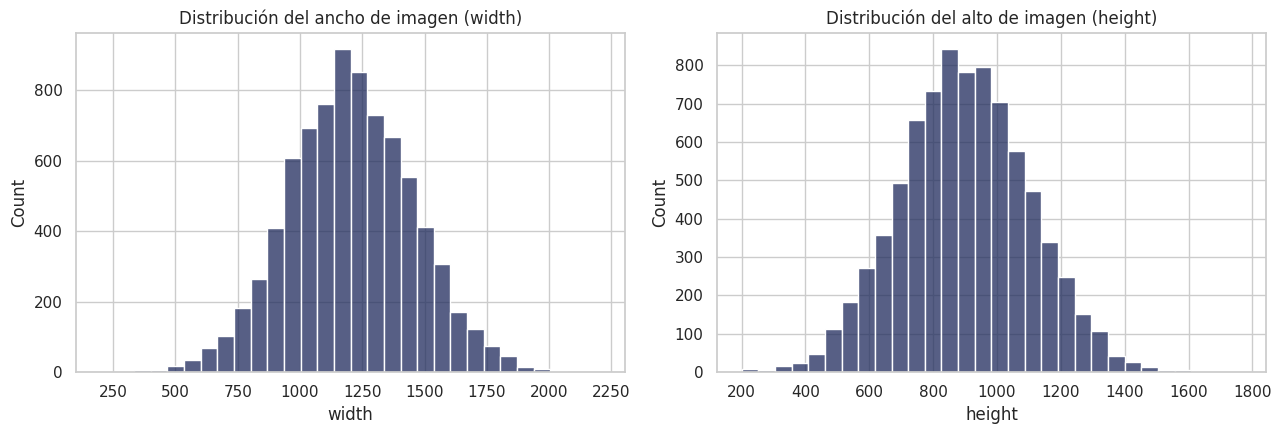

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train_df["width"], bins=30, ax=axes[0], color="#1F2A5C")
axes[0].set_title("Distribución del ancho de imagen (width)")
sns.histplot(train_df["height"], bins=30, ax=axes[1], color="#1F2A5C")
axes[1].set_title("Distribución del alto de imagen (height)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_484/833316922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="class_label", y="bbx_area_ratio", palette="crest")


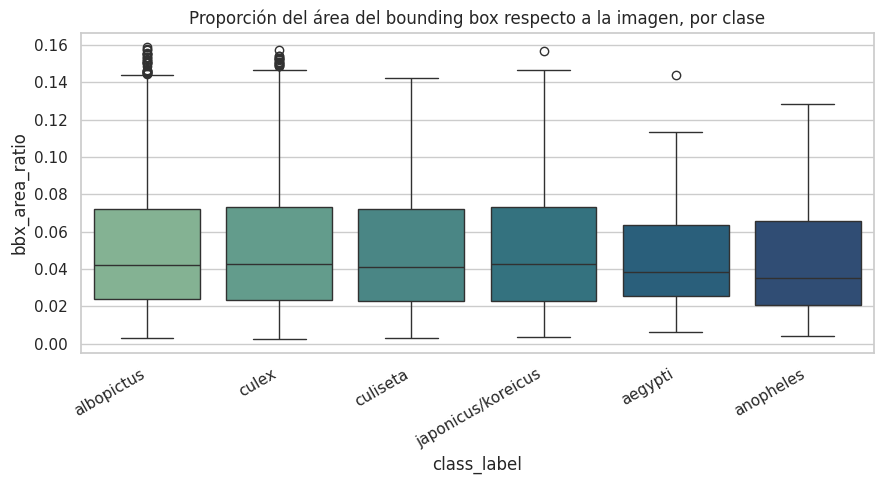

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=train_df, x="class_label", y="bbx_area_ratio", palette="crest")
plt.xticks(rotation=30, ha="right")
plt.title("Proporción del área del bounding box respecto a la imagen, por clase")
plt.tight_layout()
plt.show()


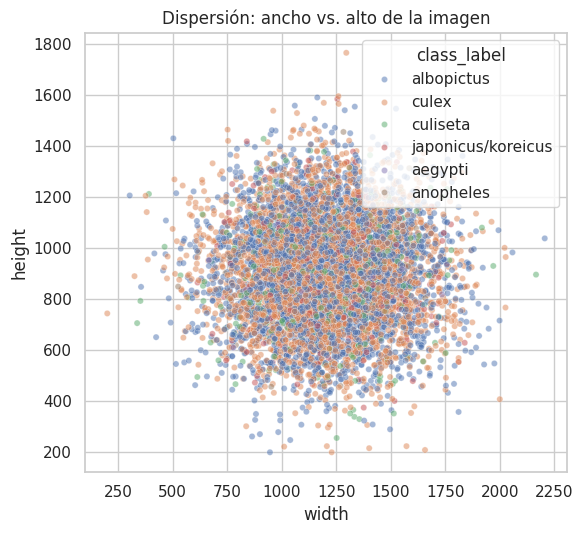

In [13]:
plt.figure(figsize=(6, 5.5))
sns.scatterplot(data=train_df, x="width", y="height", hue="class_label", alpha=0.5, s=20)
plt.title("Dispersión: ancho vs. alto de la imagen")
plt.tight_layout()
plt.show()


**Interpretación (completar):**`# TODO (Responsable: [Nombre 3])` — ¿hay outliers de
tamaño? ¿el tamaño relativo del mosquito en la imagen (`bbx_area_ratio`) varía por clase?

### 7.3 Variables categóricas — tabla de frecuencia y proporciones

**Responsable:**`[Nombre 3]`


In [14]:
freq_table = train_df["class_label"].value_counts().to_frame("frecuencia")
freq_table["proporcion_%"] = (freq_table["frecuencia"] / len(train_df) * 100).round(2)
freq_table


,frecuencia,proporcion_%
class_label,,
albopictus,3567,44.45
culex,3544,44.16
culiseta,492,6.13
japonicus/koreicus,321,4.00
anopheles,63,0.79
aegypti,38,0.47


/tmp/ipykernel_484/2578611858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, y="class_label", order=order, palette="crest")


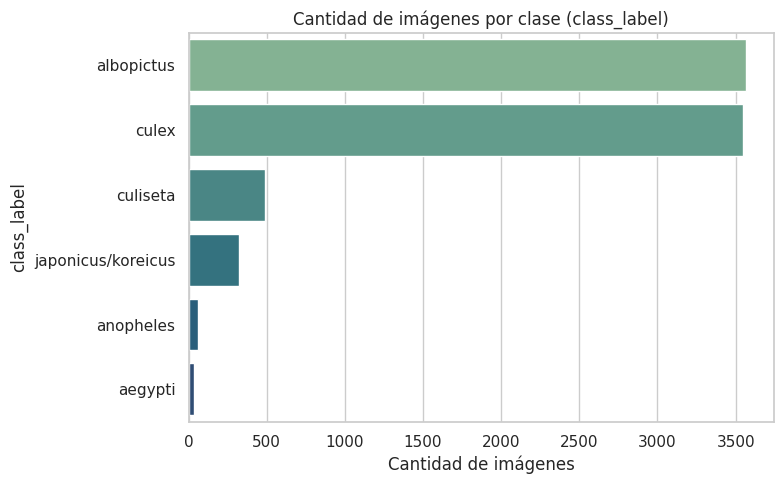

In [15]:
plt.figure(figsize=(8, 5))
order = train_df["class_label"].value_counts().index
sns.countplot(data=train_df, y="class_label", order=order, palette="crest")
plt.title("Cantidad de imágenes por clase (class_label)")
plt.xlabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()


**Interpretación (completar):**`# TODO (Responsable: [Nombre 3])` — cuantificar el
desbalance (ej. razón entre la clase mayoritaria y la minoritaria) y qué implica para el
modelado (data augmentation, class weights, muestreo, métricas como macro-F1).

### 7.4 Cruce de variables clave

**Responsable:**`[Nombre 4]`


/tmp/ipykernel_484/954594140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="class_label", y="aspect_ratio", palette="flare")


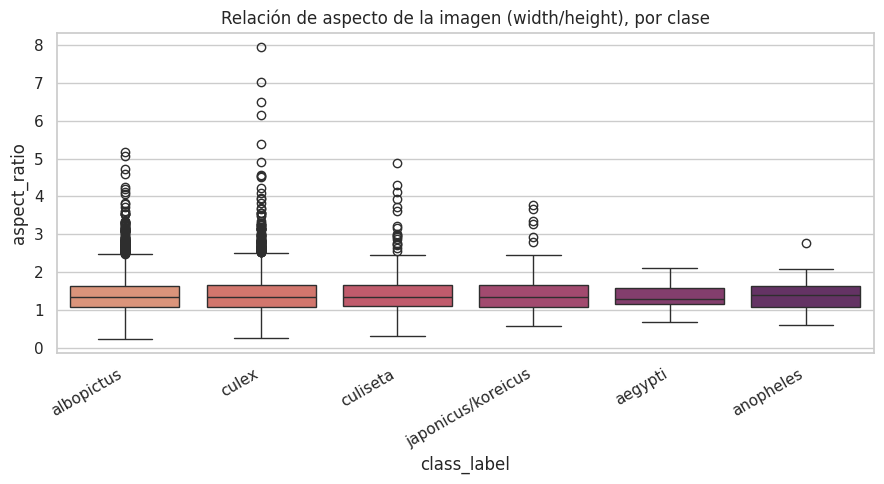

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=train_df, x="class_label", y="aspect_ratio", palette="flare")
plt.xticks(rotation=30, ha="right")
plt.title("Relación de aspecto de la imagen (width/height), por clase")
plt.tight_layout()
plt.show()


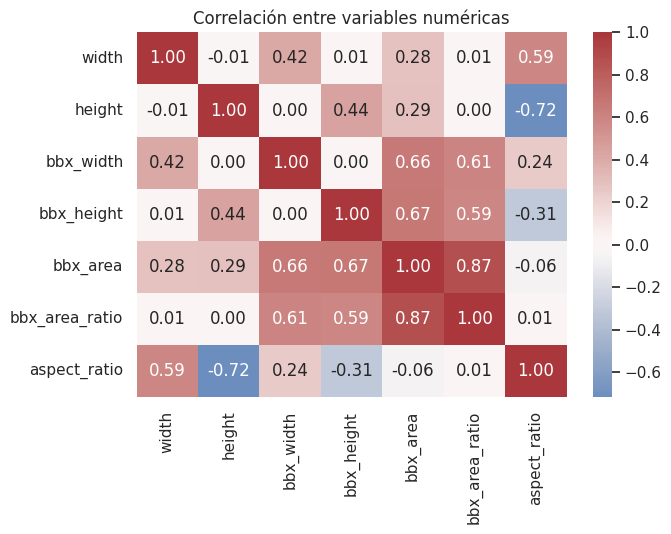

In [17]:
# Matriz de correlación entre variables numéricas derivadas
corr = train_df[numeric_cols].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()


**Interpretación (completar):**`# TODO (Responsable: [Nombre 4])` — ¿alguna variable
del bounding box está fuertemente correlacionada con otra (ej. redundancia entre `bbx_width`
y `bbx_area`)? ¿el `aspect_ratio` de la imagen depende de la clase, sugiriendo distintas fuentes
de captura por especie?

### 7.5 Valores atípicos (outliers) y valores faltantes

**Responsable:**`[Nombre 4]`


In [18]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in ["bbx_area_ratio", "aspect_ratio"]:
    out = iqr_outliers(train_df[col])
    print(f"{col}: {len(out)} outliers detectados por método IQR ({len(out)/len(train_df)*100:.1f}% del total)")


bbx_area_ratio: 39 outliers detectados por método IQR (0.5% del total)
aspect_ratio: 266 outliers detectados por método IQR (3.3% del total)


In [19]:
print("Valores faltantes por columna (revisar de nuevo tras cargar el dataset real):")
train_df.isnull().sum()

# TODO (Responsable: [Nombre 4]): si hay valores faltantes, documentar la decisión tomada
# (eliminar filas, imputar, marcar como categoría aparte) y la justificación.


Valores faltantes por columna (revisar de nuevo tras cargar el dataset real):


img_fname         0
width             0
height            0
bbx_xtl           0
bbx_ytl           0
bbx_xbr           0
bbx_ybr           0
class_label       0
bbx_width         0
bbx_height        0
bbx_area          0
image_area        0
bbx_area_ratio    0
aspect_ratio      0
dtype: int64

**Interpretación y decisiones (completar):**`# TODO (Responsable: [Nombre 4])`

### 7.6 Inspección visual de las imágenes

**Responsable:**`[Nombre 4]`

Muestra una cuadrícula con ejemplos reales de cada clase junto con su bounding box, para
detectar visualmente qué tan fácil o difícil luce el problema de clasificación.


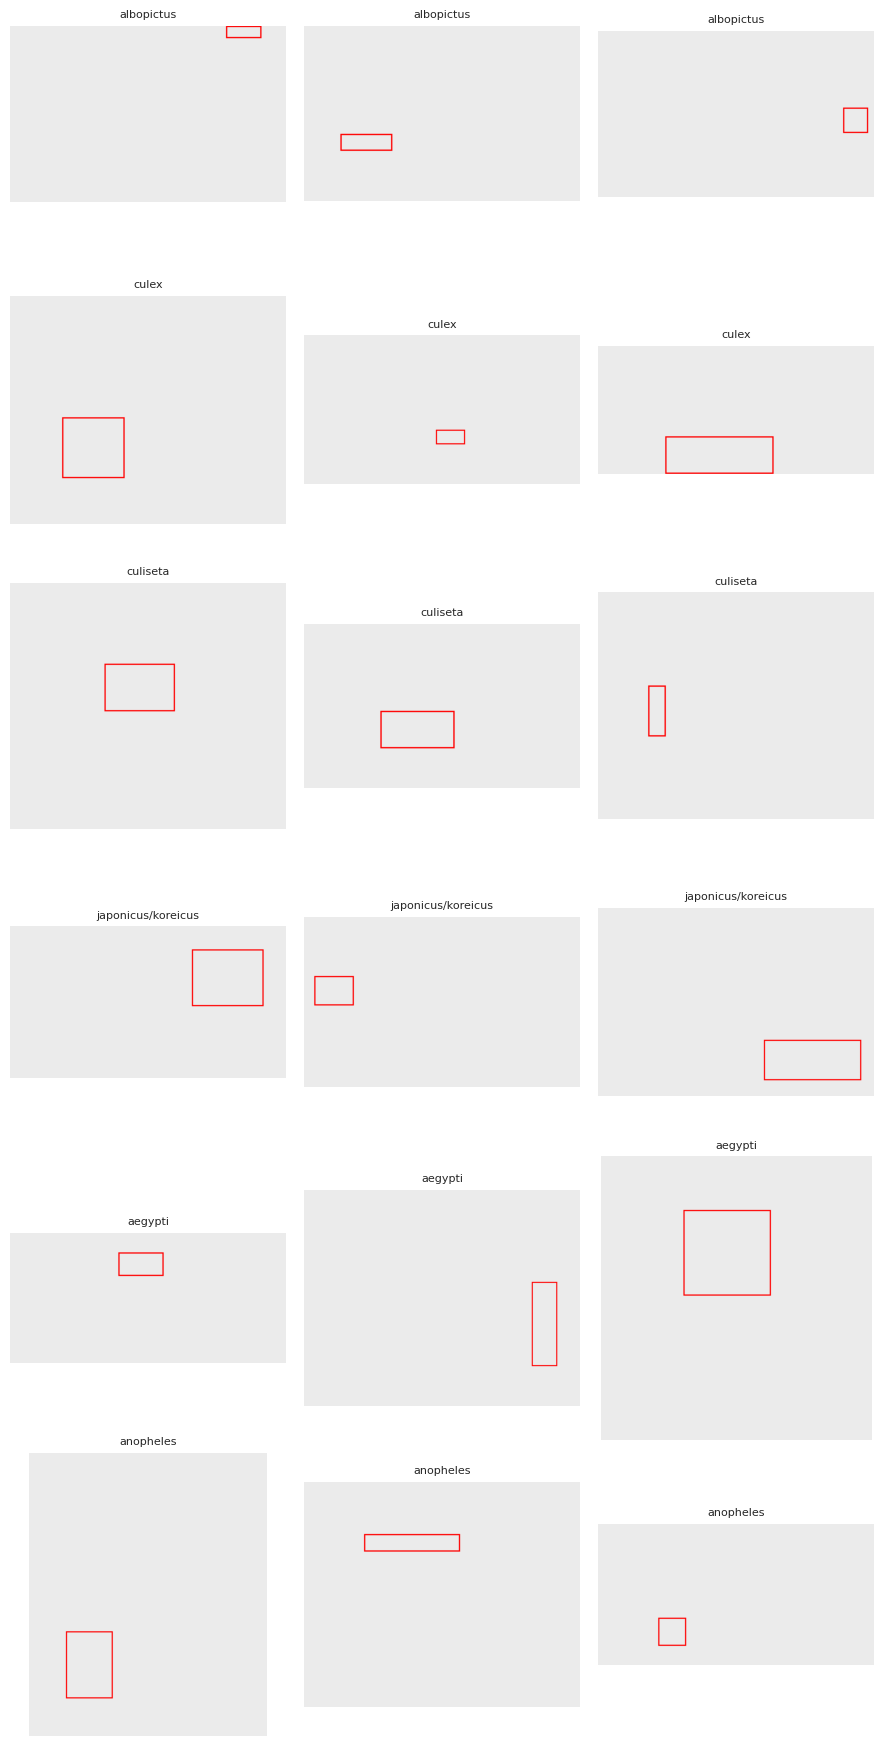

Estas son cajas sintéticas de ejemplo — repite esta celda con el dataset real para la inspección visual definitiva.


In [20]:
def show_sample_grid(df, images_dir, n_per_class=3, use_real=USE_REAL_DATA):
    classes = df["class_label"].unique()
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 3, len(classes) * 3))
    for i, cls in enumerate(classes):
        sample = df[df["class_label"] == cls].sample(min(n_per_class, (df["class_label"] == cls).sum()),
                                                       random_state=RANDOM_SEED)
        for j in range(n_per_class):
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.axis("off")
            if j >= len(sample):
                continue
            row = sample.iloc[j]
            if use_real:
                img_path = os.path.join(images_dir, row["img_fname"])
                if not os.path.exists(img_path):
                    ax.set_title("archivo no encontrado", fontsize=8)
                    continue
                img = Image.open(img_path).convert("RGB")
            else:
                # Placeholder sintético: lienzo en blanco del tamaño reportado en el CSV
                img = Image.new("RGB", (int(row["width"]), int(row["height"])), (235, 235, 235))
            draw = ImageDraw.Draw(img)
            draw.rectangle([row["bbx_xtl"], row["bbx_ytl"], row["bbx_xbr"], row["bbx_ybr"]],
                           outline="red", width=max(2, int(row["width"] / 200)))
            ax.imshow(img)
            if j == 0:
                ax.set_ylabel(cls, fontsize=9)
            ax.set_title(cls, fontsize=8)
    plt.tight_layout()
    plt.show()

show_sample_grid(train_df, IMAGES_DIR)
if not USE_REAL_DATA:
    print("Estas son cajas sintéticas de ejemplo — repite esta celda con el dataset real para "
          "la inspección visual definitiva.")


**Interpretación (completar):**`# TODO (Responsable: [Nombre 4])` — con las imágenes
reales: ¿qué tan similares se ven las clases que son difíciles de distinguir (ej. `culex` vs.
`japonicus/koreicus`)? ¿el mosquito ocupa poco espacio en la foto? ¿varía mucho la iluminación o
el fondo entre imágenes?

## 8. Hallazgos y Conclusiones  *(20 pts)*

**Responsable:**`[Todos — cada quien resume su sección, uno consolida]`

### 8.1 Resumen de hallazgos
- `# TODO` (de la sección 5–6: forma y limpieza de los datos)
- `# TODO` (de la sección 7.1–7.3: tamaño de imágenes y desbalance de clases)
- `# TODO` (de la sección 7.4–7.6: cruces, outliers e inspección visual)

### 8.2 Conclusiones y próximos pasos hacia el modelado
- `# TODO` (ej. estrategia para el desbalance: data augmentation dirigido a `aegypti`/`anopheles`,
  pesos de clase, muestreo estratificado)
- `# TODO` (ej. arquitectura a considerar: CNN + transfer learning, o detección tipo YOLO
  dado que el reto es de detección + clasificación)
- `# TODO` (ej. métrica a optimizar: Macro F1, tal como especifica la evaluación oficial del reto)
